In [1]:
%cd /home/kawamanmi/Projects/PyBaMM
import pybamm
import numpy as np


c_rates = "C/10"
no_cycles = 1
exp = pybamm.Experiment(
    [("Charge at {} until 4.2 V".format(c_rates),
      "Rest for 5 hours",
      "Discharge at {} until 2.5 V".format(c_rates),
      "Rest for 5 hours",
      )] * no_cycles,
) 
param = pybamm.ParameterValues("Chen2020")
param

/home/kawamanmi/Projects/PyBaMM


{'Ambient temperature [K]': 298.15,
 'Boltzmann constant [J.K-1]': 1.380649e-23,
 'Bulk solvent concentration [mol.m-3]': 2636.0,
 'Cation transference number': 0.2594,
 'Cell cooling surface area [m2]': 0.00531,
 'Cell thermal expansion coefficient [m.K-1]': 1.1e-06,
 'Cell volume [m3]': 2.42e-05,
 'Contact resistance [Ohm]': 0,
 'Current function [A]': 5.0,
 'EC diffusivity [m2.s-1]': 2e-18,
 'EC initial concentration in electrolyte [mol.m-3]': 4541.0,
 'Edge heat transfer coefficient [W.m-2.K-1]': 0.3,
 'Electrode height [m]': 0.065,
 'Electrode width [m]': 1.58,
 'Electrolyte conductivity [S.m-1]': <function electrolyte_conductivity_Nyman2008 at 0x7f8bf329b490>,
 'Electrolyte diffusivity [m2.s-1]': <function electrolyte_diffusivity_Nyman2008 at 0x7f8bf329b400>,
 'Electron charge [C]': 1.602176634e-19,
 'Faraday constant [C.mol-1]': 96485.33212,
 'Ideal gas constant [J.K-1.mol-1]': 8.314462618,
 'Initial concentration in electrolyte [mol.m-3]': 1000.0,
 'Initial concentration in neg

In [2]:
# D_sol = param['Outer SEI solvent diffusivity [m2.s-1]']
# c_sol = param['Bulk solvent concentration [mol.m-3]']
# F = param["Faraday constant [C.mol-1]"]
# L_sei0 = param['Initial inner SEI thickness [m]']*2
# k_sei = param['Inner SEI electron conductivity [S.m-1]']
# DD = L_sei0/(D_sol*c_sol*F)

# RR = 1/(F*k_sei*c_sol)
# print(DD)
# print(RR)

In [3]:
sei_model = "ec reaction limited"

Label_sei_models = "Solvent reaction limited"
D_SEI = [1]
Kinetic_constants = [1/1000]
sols = []
pybamm.settings.max_y_value = 1000000000
solver = pybamm.CasadiSolver(mode="safe")
for ii in Kinetic_constants:
    for i in D_SEI:
        param = pybamm.ParameterValues("Chen2020")
        param['Initial inner SEI thickness [m]'] = 1e-12
        param['Initial outer SEI thickness [m]'] = 1e-12
        param['Outer SEI solvent diffusivity [m2.s-1]'] = param['Outer SEI solvent diffusivity [m2.s-1]']/100
        param['SEI kinetic rate constant [m.s-1]'] = param['SEI kinetic rate constant [m.s-1]']*ii
        Factor = param['SEI kinetic rate constant [m.s-1]'] * \
            param['Faraday constant [C.mol-1]'] * \
            param['Bulk solvent concentration [mol.m-3]']
        print(Factor)
        model = (pybamm.lithium_ion.SPM(
            options={"SEI": sei_model, "SEI porosity change": "true"},
            name=sei_model))
        sim = (pybamm.Simulation(model, parameter_values=param,
                                 experiment=exp, solver=solver))
        sols.append(sim.solve(initial_soc=0))

2.5433533546832e-07


In [4]:
out_vars = ['X-averaged negative total SEI thickness [m]', 'X-averaged negative particle surface concentration [mol.m-3]',
            "Voltage [V]",
            ]

In [5]:
param_R = pybamm.ParameterValues("Chen2020")
param_R['Initial inner SEI thickness [m]'] = 1e-12
param_R['Initial outer SEI thickness [m]'] = 1e-12
param_R['SEI reaction exchange current density [A.m-2]'] = 2.5433446e-7
model_R = (pybamm.lithium_ion.SPM(
    options={"SEI": "reaction limited", "SEI porosity change": "true"},
    name=sei_model))
sim_R = (pybamm.Simulation(model_R, parameter_values=param_R,
                           experiment=exp, solver=solver))
sol_R = sim_R.solve(initial_soc=0)

param_D = pybamm.ParameterValues("Chen2020")
param_D['Initial inner SEI thickness [m]'] = 1e-12
param_D['Initial outer SEI thickness [m]'] = 1e-12
model_D = (pybamm.lithium_ion.SPM(
    options={"SEI": "solvent-diffusion limited",
             "SEI porosity change": "true"},
    name=sei_model))
sim_D = (pybamm.Simulation(model_D, parameter_values=param_D,
                           experiment=exp, solver=solver))
sol_D = sim_D.solve(initial_soc=0)

In [6]:
# model_D.variable_names()

1


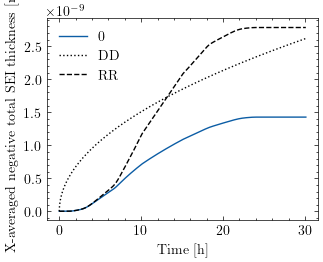

In [7]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import scienceplots
import matplotlib.cm as cm

plt.style.use('science')  # Use the 'science' style
cmap = cm.get_cmap('tab10')  # Colour map (there are many others)
out_vars = ['X-averaged negative total SEI thickness [m]', 'X-averaged negative particle surface concentration [mol.m-3]',
            "Voltage [V]",
            ]
print(len(sols))
for index in range(len(sols)):
    plt.plot(sols[index]["Time [h]"].entries,
             sols[index][out_vars[0]].entries, label=index)
plt.plot(sol_D["Time [h]"].entries, sol_D[out_vars[0]].entries,
         label="DD", color='black', linestyle=':')
plt.plot(sol_R["Time [h]"].entries, sol_R[out_vars[0]].entries,
         label="RR", color='black', linestyle='--')
plt.xlabel("Time [h]")
plt.ylabel(out_vars[0])
plt.legend()